In [1]:
import cv2
import keras
import numpy as np
import pandas as pd
import tensorflow as tf
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import os

In [ ]:
# os.environ["KERAS"]

In [6]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()

In [4]:
type(fashion_mnist)

tuple

In [94]:
(train_images, train_labels), (test_images, test_labels) = fashion_mnist

In [74]:
train_images.shape

(60000, 28, 28)

In [75]:
train_images[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  

In [95]:
train_images = np.expand_dims(train_images, -1)
train_labels = np.expand_dims(train_labels, -1)

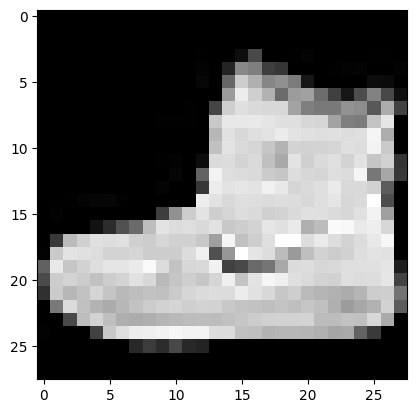

In [96]:
plt.imshow(train_images[0].reshape(28, 28), cmap="gray")
plt.savefig("shoe.jpg")
plt.show()

In [97]:
train_images.astype(np.float32).ndim

4

In [99]:
train_labels.astype(np.float32).ndim

2

In [49]:
img = cv2.imread("shoe.jpg")

In [52]:
img

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

In [50]:
gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [51]:
gray_image

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], shape=(480, 640), dtype=uint8)

In [81]:
model = tf.keras.Sequential()
model.add(tf.keras.Input((28, 28, 1)))
model.add(tf.keras.layers.Dense(units=512, activation=tf.nn.relu, name="layer0"))
model.add(
    tf.keras.layers.Dense(units=10, activation=tf.nn.softmax, name="output_recheck_why")
)

In [82]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer0 (Dense)                  │ (None, 28, 28, 512)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_recheck_why (Dense)      │ (None, 28, 28, 10)     │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,154 (24.04 KB)

 Trainable params: 6,154 (24.04 KB)

 Non-trainable params: 0 (0.00 B)

In [127]:
from keras.src.layers import Conv2D


def model_arch():
    models = tf.keras.Sequential()

    # We are learning 64
    # filters with a kernel size of 5x5
    models.add(
        Conv2D(64, (5, 5), padding="same", activation="relu", input_shape=(28, 28, 1))
    )

    # Max pooling will reduce the
    # size with a kernel size of 2x2
    models.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
    models.add(Conv2D(128, (5, 5), padding="same", activation="relu"))

    models.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
    models.add(Conv2D(256, (5, 5), padding="same", activation="relu"))
    #
    models.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
    #
    # # Once the convolutional and pooling
    # # operations are done the layer
    # # is flattened and fully connected layers
    # # are added
    models.add(tf.keras.layers.Flatten())
    models.add(tf.keras.layers.Dense(256, activation="relu"))
    #
    # Finally as there are total 10
    # classes to be added a FCC layer of
    # 10 is created with a softmax activation
    # function
    models.add(
        tf.keras.layers.Dense(10, activation=tf.nn.softmax_cross_entropy_with_logits)
    )
    return models

In [128]:
model = model_arch()

/Users/ankster/.virtualenvs/ML_AI/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [129]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14, 14, 10)     │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 207,882 (812.04 KB)

 Trainable params: 207,882 (812.04 KB)

 Non-trainable params: 0 (0.00 B)

In [131]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.losses.MeanSquaredError],
)

In [108]:
train_labels[0]

np.uint8(9)

In [109]:
train_images.shape, train_labels.shape

((60000, 784), (60000,))

In [67]:
train_labels.shape

(60000, 1)

In [132]:
import tqdm

(
    model.fit(
        train_images.astype(np.float32),
        train_labels.astype(np.float32),
        epochs=1,
        validation_split=0.2,
        verbose=1,
    )
)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 90s 60ms/step - loss: 77069.1406 - mean_squared_error: 27.6817 - val_loss: 2.3161 - val_mean_squared_error: 27.3253


In [ ]:
logits = model(train_images)

In [133]:
predictions = tf.nn.softmax(logits)

In [134]:
history

{'loss': [77069.140625],
 'mean_squared_error': [27.681737899780273],
 'val_loss': [2.316052198410034],
 'val_mean_squared_error': [27.325252532958984]}

# Mnist

In [ ]:
(train_images, train_labels), (test_images, test_labels) = (
    tf.keras.datasets.mnist.load_data()
)

In [1]:
# todo code a full training loop from scratch like shown in Machine Learning Rascha Chapter 11.2 Classiying mnist.. will help understand

In [ ]:
train_images = train_images.reshape((60000, 28 * 28))

In [ ]:
test_images = test_images.reshape((10000, 28 * 28))

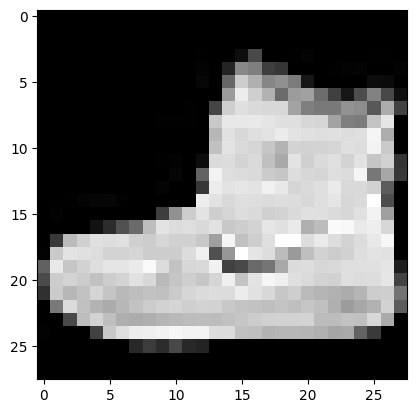

In [68]:
plt.imshow(train_images[0].reshape((28, 28)), cmap="gray")
plt.show()